# 1D FDTD Solver: Fabry-Pérot Cavity and Frequency Domain Analysis

A Fabry-Pérot cavity consists of two partially reflective interfaces enclosing a medium of length $L_\text{slab}$. When a wave enters the cavity, it bounces back and forth between the interfaces. There are specific **resonant frequencies** for which the round-trip phase shift is a multiple of $2\pi$. This leads to constructive interference and maximum transmission. These frequencies read

$$f_m = \frac{m c_0}{2 L_\text{slab} \sqrt{\varepsilon_r}}, \quad m = 1, 2, 3, \ldots$$

Between resonances, destructive interference reduces the transmission. The sharpness of the resonance peaks is controlled by the reflectivity of the interfaces: higher $\varepsilon_r$ means stronger reflections and sharper peaks.

The transmission spectrum is described analytically by the **Airy distribution**:

$$|H(f)|^2 = \frac{(1-R)^2}{(1-R)^2 + 4R\sin^2\left(\frac{2\pi f L_\text{slab} \sqrt{\varepsilon_r}}{c_0}\right)},$$

where $R = r^2 = \left(\frac{1 - \sqrt{\varepsilon_r}}{1 + \sqrt{\varepsilon_r}}\right)^2$ is the power reflectivity at each interface. The transfer function $H(f)$ measures the response of the system via

$$E_{\text{trans}}(f) = H(f) E_{\text{inc}}(f),$$

where $E_{\text{inc}}(f)$ is the field incident on the cavity and $E_{\text{trans}}(f)$ is the field transmitted to the other side of the cavity. Both $E_{\text{inc}}(f)$ and $E_{\text{trans}}(f)$ are supposed to be measured at two points far away from the cavity, ideally at $x_{\text{inc}} = -\infty$ and $x_{\text{trans}} = +\infty$. In this way, $H(f)$ quantifies what the cavity does to the electromagnetic pulse when it travels between two asymptotically far away points. 

In this notebook we extract the transmission spectrum of a Fabry-Pérot cavity using **broadband FDTD simulation and Fourier analysis**. A single Gaussian pulse excites all frequencies simultaneously; the transfer function $H(f) = E_\text{trans}(f) / E_\text{inc}(f)$ then gives the full frequency response in one simulation run. We then compare the numerically obtained transfer function with the analytical result given above.

In [107]:
import importlib
import src.analysis
importlib.reload(src.analysis)
from src.analysis import compute_transfer_function, FieldProbe, find_peak

import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from functools import partial

from src.grid import Grid
from src.solver import FDTDSolver1D
from src.sources import SoftSource, gaussian_pulse
from src.boundaries import SimpleABC
from src.materials import add_material_slab
from src.analysis import compute_transfer_function, FieldProbe

rc_fonts = {
    "font.family"      : "serif",
    "font.size"        : 10,
    "mathtext.fontset" : "cm",
    "font.serif"       : ["CMU Serif"],
    "animation.embed_limit": 50
}
mpl.rcParams.update(rc_fonts)

## Domain layout

We create a domain of length $1 \,\mathrm{m}$ and introduce a dielectric slab in the region $0.35 \,\mathrm{m} \leq x \leq 0.65 \,\mathrm{m}$. Two `FieldProbe` objects record the field at fixed positions over time:

- **Incident probe** at $x = 0.1$ m — records the incident field before 
  the cavity
- **Transmitted probe** at $x = 0.9$ m — records the transmitted field 
  after the cavity

The ratio of their Fourier transforms gives the transfer function $H(f)$.

We run the simulation long enough for the cavity to fully ring down, i.e., until the field inside has decayed to near zero. For a high-$Q$ cavity (that is, one that stores light very well) this requires many round trips and a correspondingly long simulation time.

In [108]:
# Physical parameters
L             = 1.0
x_src         = 0.05
x_slab_start  = 0.35
x_slab_end    = 0.65
L_slab        = x_slab_end - x_slab_start
x_inc_probe   = 0.1     # incident field probe position
x_trans_probe = 0.9     # transmitted field probe position
dx            = 5e-4
courant       = 0.5
t0            = 5e-10
sigma         = 1e-10   # broadband pulse
amplitude     = 1.0
c0            = 299792458.0

# Material
eps_r = 4.0

# Resonant frequencies
print("Resonant frequencies:")
for m in range(1, 6):
    f_m = m * c0 / (2 * L_slab * np.sqrt(eps_r))
    print(f"  m={m}: f_{m} = {f_m/1e9:.3f} GHz")

# Pulse bandwidth
f_bandwidth = 1 / sigma
print(f"\nPulse bandwidth: ~{f_bandwidth/1e9:.2f} GHz")
print(f"Number of resonances in bandwidth: ~{int(f_bandwidth * 2 * L_slab * np.sqrt(eps_r) / c0)}")

Resonant frequencies:
  m=1: f_1 = 0.250 GHz
  m=2: f_2 = 0.500 GHz
  m=3: f_3 = 0.749 GHz
  m=4: f_4 = 0.999 GHz
  m=5: f_5 = 1.249 GHz

Pulse bandwidth: ~10.00 GHz
Number of resonances in bandwidth: ~40


## Simulation duration

For a high-$Q$ cavity, energy leaks out slowly and we need to run long enough for the cavity to ring down. The cavity $Q$-factor is approximately:

$$Q \approx \frac{\pi \sqrt{R}}{1 - R} \cdot m$$

where $R$ is the power reflectivity. The ring-down time is:

$$\tau \approx \frac{Q}{2\pi f_m}$$

We run for several ring-down times to ensure the field has fully decayed, 
which gives clean spectral resolution.

In [109]:
# Estimate ring-down time
from src.analysis import find_peak  # reuse for Fresnel r

r_fresnel = (1 - np.sqrt(eps_r)) / (1 + np.sqrt(eps_r))
R         = r_fresnel**2
f1        = c0 / (2 * L_slab * np.sqrt(eps_r))
Q         = np.pi * np.sqrt(R) / (1 - R)
tau       = Q / (2 * np.pi * f1)

print(f"Power reflectivity R = {R:.4f}")
print(f"Q factor (m=1): {Q:.2f}")
print(f"Ring-down time: {tau*1e9:.2f} ns")

# Run for 5 ring-down times to be safe
t_end   = max(5 * tau, 5e-8)
print(f"\nSimulation duration: {t_end*1e9:.2f} ns")

Power reflectivity R = 0.1111
Q factor (m=1): 1.18
Ring-down time: 0.75 ns

Simulation duration: 50.00 ns


## Probe time series

Before computing the transfer function, we inspect the time series at both probe positions. The incident probe shows the initial Gaussian pulse, followed by an inverted pulse shortly after and then a series of non-inverted ones spaced equally. The inverted pulse corresponds to the reflected part of the pulse after incidence on the cavity. The non-inverted pulses are the parts that leak out of the cavity after being reflected at its end. Meanwhile, the transmitted probe simply shows a series of decaying pulses, corresponding to the part that made it out of the cavity followed by a decaying tail of successive round trips leaking out of the cavity. This ring-down tail is the time-domain signature of the cavity resonances.

While this is working well, to get $H(f)$ we actually only want the part of the incident pulse that is not reflected back, i.e., only the initial pulse. For this reason we also run a simulation without any slab, to capture only this incident part.

In [110]:
grid = Grid(L=L, dx=dx, courant=courant)
n_steps       = round(t_end / grid.dt)
print(f"Total timesteps: {n_steps}")

wf     = partial(gaussian_pulse, t0=t0, sigma=sigma, amplitude=amplitude)
source = SoftSource(grid, position=x_src, waveform_func=wf)

abc    = SimpleABC()
abc.setup(grid)
solver = FDTDSolver1D(grid, [source], [abc])

# Field probe (incident)
probe_inc   = FieldProbe(grid, position=x_inc_probe)

field_history = []

for n in range(n_steps):
    solver.step(n)
    probe_inc.measure(grid)
    probe_trans.measure(grid)
    t = n * grid.dt
    field_history.append(grid.Ez.copy())
    
print("Done (without slab).")

add_material_slab(grid, x_start=x_slab_start, x_end=x_slab_end, eps_r=eps_r)

abc    = SimpleABC()
abc.setup(grid)
solver = FDTDSolver1D(grid, [source], [abc])

# Field probes (incident and transmitted)
probe_inc_full = FieldProbe(grid, position=x_inc_probe)
probe_trans    = FieldProbe(grid, position=x_trans_probe)

field_history = []

for n in range(n_steps):
    solver.step(n)
    probe_inc_full.measure(grid)
    probe_trans.measure(grid)
    t = n * grid.dt
    field_history.append(grid.Ez.copy())
    
print("Done (with slab).")

Total timesteps: 59958
Done (without slab).
Done (with slab).


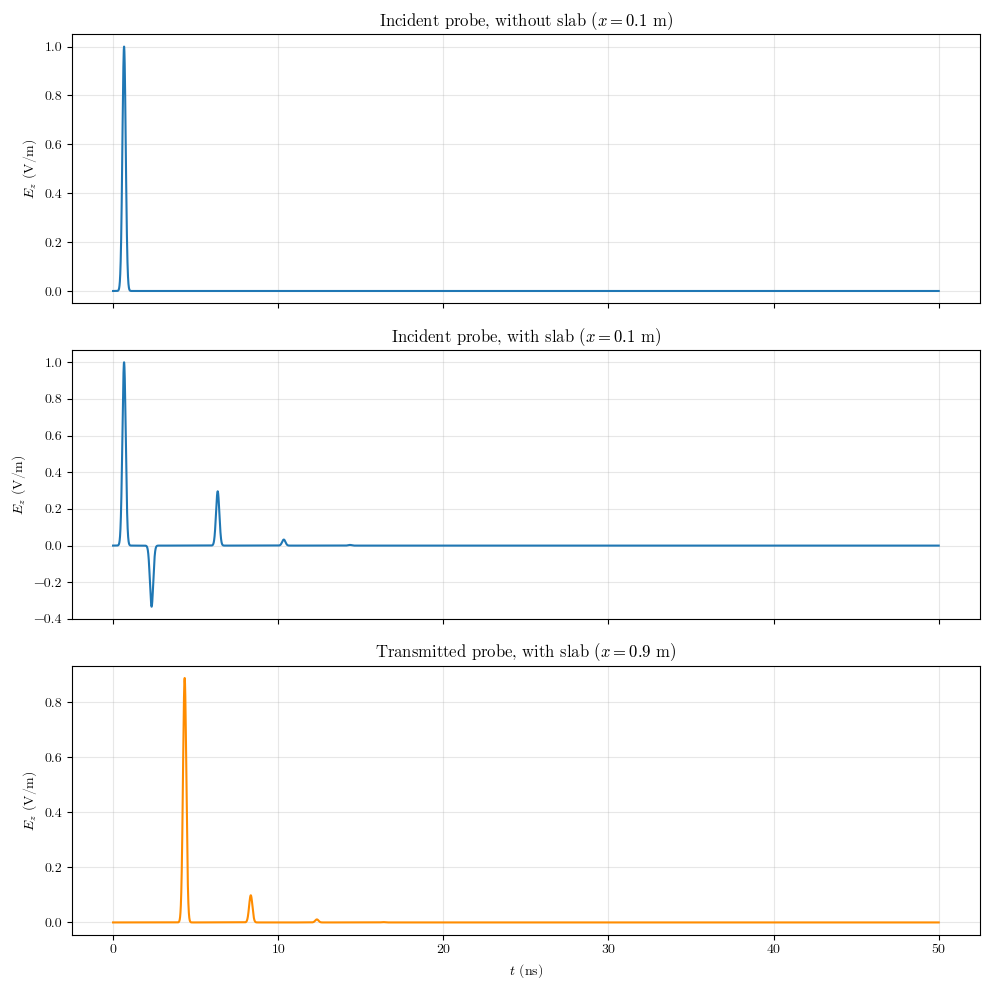

In [111]:
inc_series      = probe_inc.get_series()
inc_series_full = probe_inc_full.get_series()
trans_series    = probe_trans.get_series()
times           = np.arange(len(inc_series)) * grid.dt

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

ax1.plot(times * 1e9, inc_series)
ax1.set_ylabel('$E_z$ (V/m)')
ax1.set_title('Incident probe, without slab ($x = 0.1$ m)')
ax1.grid(True, alpha=0.3)

ax2.plot(times * 1e9, inc_series_full)
ax2.set_ylabel('$E_z$ (V/m)')
ax2.set_title('Incident probe, with slab ($x = 0.1$ m)')
ax2.grid(True, alpha=0.3)

ax3.plot(times * 1e9, trans_series, color='darkorange')
ax3.set_ylabel('$E_z$ (V/m)')
ax3.set_xlabel('$t$ (ns)')
ax3.set_title('Transmitted probe, with slab ($x = 0.9$ m)')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../assets/04_probe_timeseries.png', dpi=300)
plt.show()

## Transfer function

Now we compute the transfer function $H(f) = E_\text{trans}(f) / E_\text{inc}(f)$ and compare $H(f)$ to the analytical Airy distribution. Resonance peaks should appear at the predicted frequencies $f_m = m c_0 / (2 L_\text{slab} \sqrt{\varepsilon_r})$.

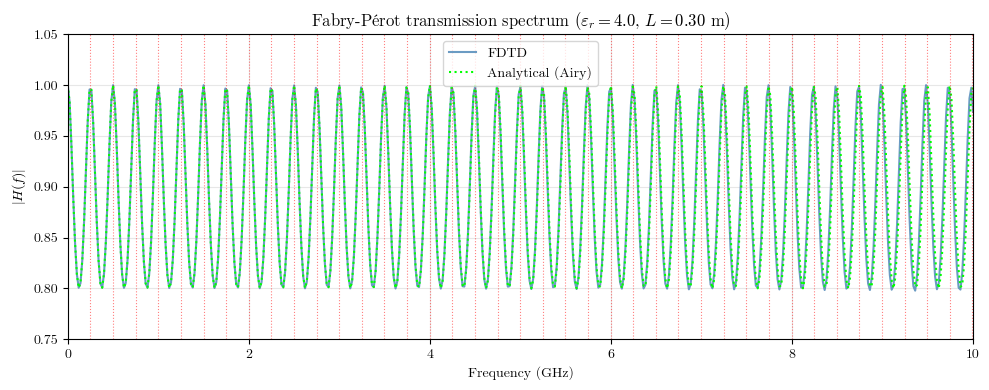

In [130]:
freqs, H_amp, H_phase, E_inc, E_trans = compute_transfer_function(
    inc_series, trans_series, grid.dt, window=False
)

# Analytical Airy function
def airy_distr(f, L_slab, eps_r, c0):
    R   = ((1 - np.sqrt(eps_r)) / (1 + np.sqrt(eps_r)))**2
    phi = 2 * np.pi * f * L_slab * np.sqrt(eps_r) / c0
    return (1 - R)**2 / ((1 - R)**2 + 4 * R * np.sin(phi)**2)

H_airy = np.sqrt(airy_distr(freqs, L_slab, eps_r, c0))

# Resonant frequencies
f_resonances = [m * c0 / (2 * L_slab * np.sqrt(eps_r)) for m in range(1, 50)]

# Plot
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(freqs / 1e9, H_amp,   label='FDTD', color='steelblue', alpha=0.8)
ax.plot(freqs / 1e9, H_airy,  label='Analytical (Airy)', color='lime',
        linestyle=':', linewidth=1.5)
ax.set_ylim(0.75, 1.05)

for f_m in f_resonances:
    ax.axvline(f_m / 1e9, color='red', linestyle=':', alpha=0.5, linewidth=0.8)

ax.set_xlabel('Frequency (GHz)')
ax.set_ylabel('$|H(f)|$')
ax.set_title(f'Fabry-Pérot transmission spectrum ($\\varepsilon_r = {eps_r}$, '
             f'$L = {L_slab:.2f}$ m)')
ax.set_xlim(0, f_bandwidth / 1e9)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../assets/04_fabry_perot_spectrum.png', dpi=300)
plt.show()

Clearly, we find excellent agreement between the analytical Airy result and that of the simulation within the pulse bandwidth.